## Experiment 7
#### CNN Image Classification using CIFAR 10

Importing required libraries for deep learning and visualization.

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

Load training and testing data.





In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Normalize Data : Pixel values are 0–255 → convert to 0–1 for faster training.

In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0

Define Class Names

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

Visualize Sample Images

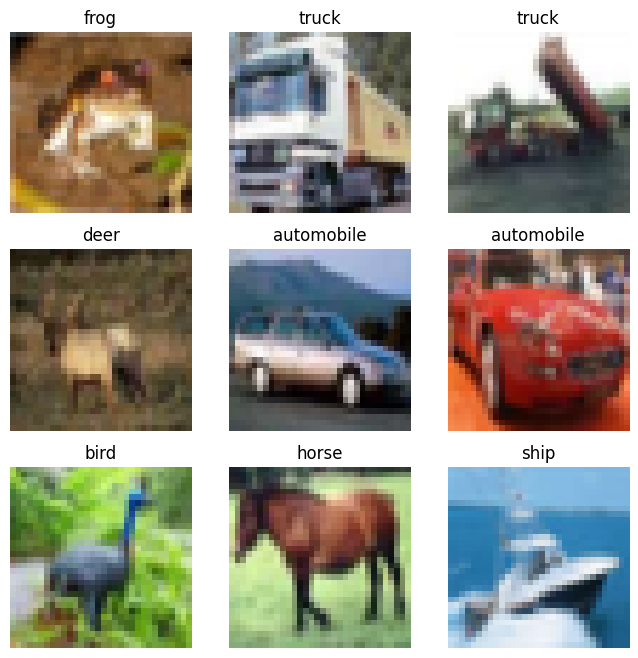

In [7]:
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(train_images[i])
    plt.title(class_names[train_labels[i][0]])
    plt.axis('off')
plt.show()

Build CNN Model

In [8]:
model = models.Sequential()

# Convolution + Pooling
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

# Fully Connected
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [9]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

Train Model

In [11]:
history = model.fit(train_images, train_labels, epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 73s 46ms/step - accuracy: 0.8108 - loss: 0.5327 - val_accuracy: 0.7067 - val_loss: 0.9313
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 71s 46ms/step - accuracy: 0.8248 - loss: 0.4960 - val_accuracy: 0.7112 - val_loss: 0.9248
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 45ms/step - accuracy: 0.8371 - loss: 0.4618 - val_accuracy: 0.7100 - val_loss: 0.9795
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.8446 - loss: 0.4325 - val_accuracy: 0.6989 - val_loss: 1.0659
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 44ms/step - accuracy: 0.8584 - loss: 0.3947 - val_accuracy: 0.7010 - val_loss: 1.0583
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.8666 - loss: 0.3715 - val_accuracy: 0.7069 - val_loss: 1.0766
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 70s 45ms/step - accuracy: 0.8764 - loss: 0.3440 - val_accuracy: 0.6938 - val_loss: 1.1726
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 47ms/step - accuracy: 0.8848 -

Evaluate Model

In [12]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6902 - loss: 1.3298
Test Accuracy: 0.6901999711990356


Plot Accuracy Graph

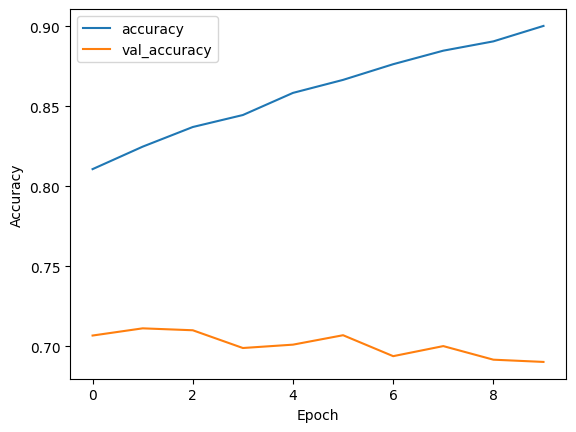

In [13]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

TESTING....

In [14]:
import numpy as np

index = 0  # you can change this
img = test_images[index]

(np.float64(-0.5), np.float64(31.5), np.float64(31.5), np.float64(-0.5))

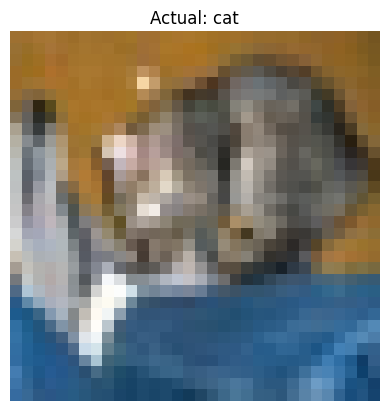

In [15]:
plt.imshow(img)
plt.title("Actual: " + class_names[test_labels[index][0]])
plt.axis('off')

In [16]:
img = np.expand_dims(img, axis=0)  # reshape

predictions = model.predict(img)
predicted_class = class_names[np.argmax(predictions)]

print("Predicted:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
Predicted: cat


Testing with own image

In [17]:
from google.colab import files
uploaded = files.upload()

Saving img.jpg to img.jpg


In [18]:
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

In [19]:
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]

print("Predicted Class:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Predicted Class: truck
